In [1]:
from google.colab import files
uploaded = files.upload()

Saving features_dataset.csv to features_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("features_dataset.csv")
df.head()

,date,team,opponent,team_goals,opponent_goals,tournament,city,country,neutral,result,...,win,team_avg_goals_last5,team_avg_conceded_last5,team_win_rate_last5,opp_avg_goals_last5,opp_avg_conceded_last5,opp_win_rate_last5,goals_diff_last5,conceded_diff_last5,win_rate_diff
0,1877-03-03,England,Scotland,1.0,3.0,Friendly,London,England,False,Away Win,...,0,1.4,1.8,0.2,2.6,1.4,0.6,-1.2,0.4,-0.4
1,1877-03-03,Scotland,England,3.0,1.0,Friendly,London,England,False,Away Win,...,1,2.6,1.4,0.6,1.4,1.8,0.2,1.2,-0.4,0.4
2,1878-03-02,Scotland,England,7.0,2.0,Friendly,Glasgow,Scotland,False,Home Win,...,1,2.8,0.6,0.8,1.6,2.4,0.2,1.2,-1.8,0.6
3,1878-03-02,England,Scotland,2.0,7.0,Friendly,Glasgow,Scotland,False,Home Win,...,0,1.6,2.4,0.2,2.8,0.6,0.8,-1.2,1.8,-0.6
4,1879-04-05,England,Scotland,5.0,4.0,Friendly,London,England,False,Home Win,...,1,1.4,3.2,0.2,5.0,0.6,1.0,-3.6,2.6,-0.8


In [3]:
features = [
    'team_avg_goals_last5',
    'team_avg_conceded_last5',
    'opp_avg_goals_last5',
    'opp_avg_conceded_last5',
    'goals_diff_last5',
    'conceded_diff_last5',
    'win_rate_diff'
]

X = df[features]
y = df['win']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.66      0.73      0.69     11876
           1       0.48      0.40      0.44      7344

    accuracy                           0.60     19220
   macro avg       0.57      0.57      0.57     19220
weighted avg       0.59      0.60      0.60     19220

[[8655 3221]
 [4379 2965]]


In [8]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5945884054896238


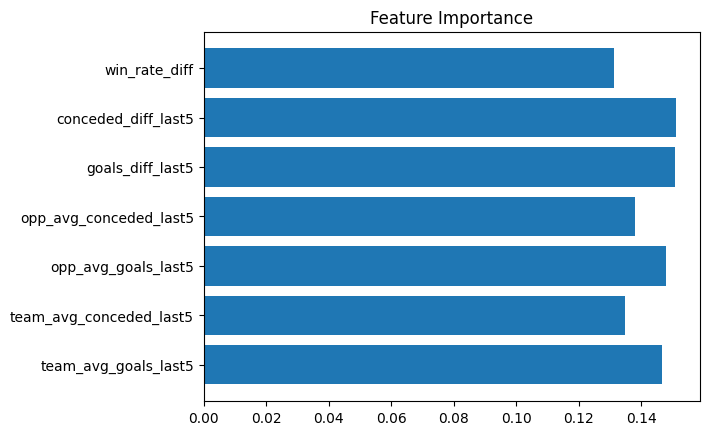

In [9]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.show()